# Рабочая тетрадь по ПСИИ №7

## Выполнил: студент группы БФБО-06-24 Петров Артем

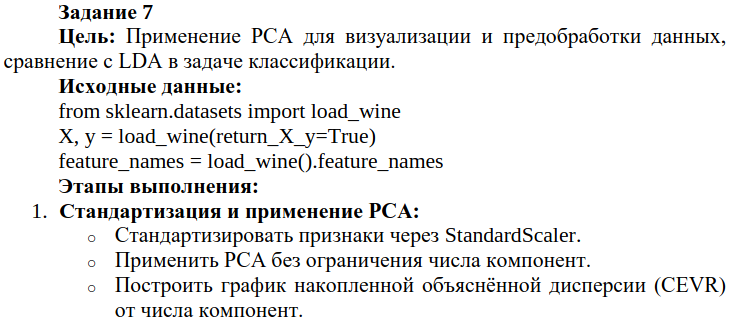

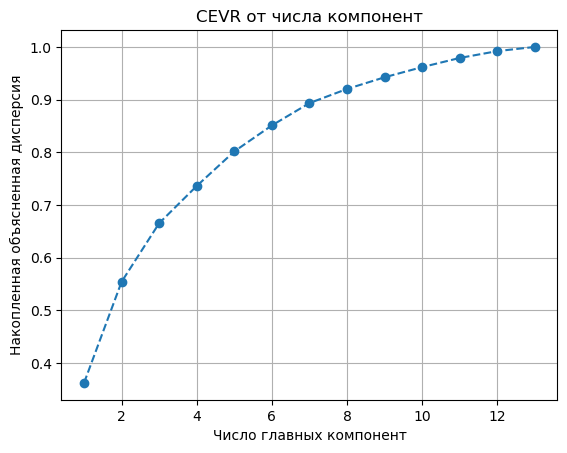

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X, y = load_wine(return_X_y = True)
feature_names = load_wine().feature_names

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA без ограничений числа компонент
PCA_model = PCA(n_components = None)
PCA_model.fit(X_scaled)

# Накопленная объясненная дисперсия
exp_disp = np.cumsum(PCA_model.explained_variance_ratio_)

# Построение графика:
plt.plot(range(1, len(exp_disp) + 1), exp_disp, marker = 'o', linestyle = '--')
plt.xlabel('Число главных компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('CEVR от числа компонент')
plt.grid()
plt.show()

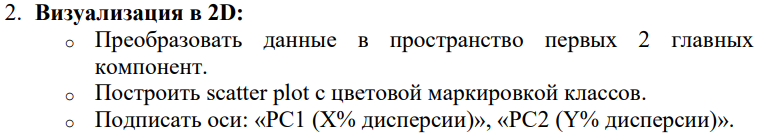

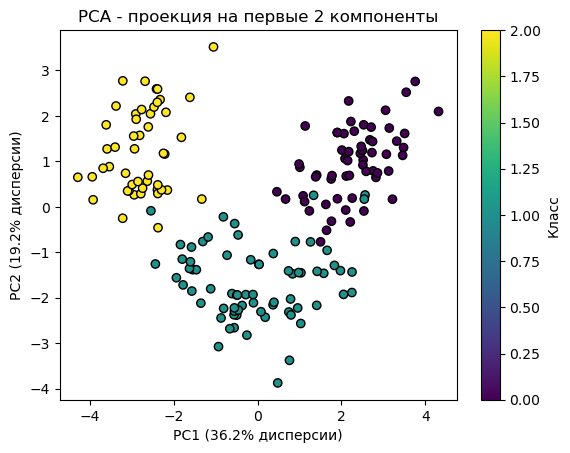

In [38]:
# Создание модели с 2 главными компонентами
PCA_model2 = PCA(n_components = 2)

# Обучение модели и сохранение в переменную
PCA_model22 = PCA_model2.fit_transform(X_scaled)

# Доли дисперсии
var1 = PCA_model2.explained_variance_ratio_[0] * 100
var2 = PCA_model2.explained_variance_ratio_[1] * 100

# Визуализация
scatter = plt.scatter(PCA_model22[:, 0], PCA_model22[:, 1], c = y, cmap = 'viridis', edgecolor = 'k')
plt.xlabel(f'PC1 ({var1:.1f}% дисперсии)')
plt.ylabel(f'PC2 ({var2:.1f}% дисперсии)')
plt.title('PCA - проекция на первые 2 компоненты')
plt.colorbar(scatter, label = 'Класс')
plt.show()

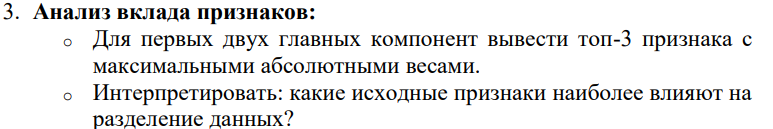

In [39]:
# Веса признаков для PC1 и PC2
loadings = PCA_model2.components_.T

# Топ-3 признака
top3_pc1_idx = np.argsort(np.abs(loadings[:, 0]))[-3:][::-1]
top3_pc2_idx = np.argsort(np.abs(loadings[:, 1]))[-3:][::-1]


# Вывод признаков
print('Топ-3 признака для PC1:')
for i in top3_pc1_idx:
    print(f'{feature_names[i]}: {loadings[i, 0]}')

print('\nТоп-3 признака для PC2:')
for i in top3_pc2_idx:
    print(f'{feature_names[i]}: {loadings[i, 1]}')

Топ-3 признака для PC1:
flavanoids: 0.4229342967100593
total_phenols: 0.39466084506663035
od280/od315_of_diluted_wines: 0.3761674107387129

Топ-3 признака для PC2:
color_intensity: 0.5299956720700438
alcohol: 0.483651547817214
proline: 0.36490283179808214


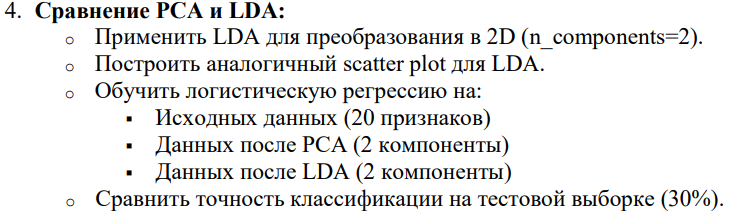

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

# LDA
LDA_model = LinearDiscriminantAnalysis(n_components = 2)
X_train_LDA = LDA_model.fit_transform(X_train, y_train)
X_test_LDA = LDA_model.transform(X_test)

# PCA
PCA_train = PCA(n_components = 2)
X_train_PCA = PCA_train.fit_transform(X_train)
X_test_PCA = PCA_train.transform(X_test)

# Создание модели логистической регрессии:
LR = LogisticRegression(max_iter = 1000)

# Обучение/переобучение модели и сохранение результатов с точностью:
# Исходные данные
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)
acc_orig = accuracy_score(y_test, y_pred)

# PCA
LR.fit(X_train_PCA, y_train)
y_pred_PCA = LR.predict(X_test_PCA)
acc_PCA = accuracy_score(y_test, y_pred_PCA)

# LDA
LR.fit(X_train_LDA, y_train)
y_pred_LDA = LR.predict(X_test_LDA)
acc_LDA = accuracy_score(y_test, y_pred_LDA)

# Вывод результатов
print(f'Точность: \nСтоковые данные: {acc_orig};\nPCA: {acc_PCA}; \nLDA: {acc_LDA}.')

Точность: 
Стоковые данные: 0.9814814814814815;
PCA: 0.6851851851851852; 
LDA: 0.9814814814814815.


C:\Users\artsk\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


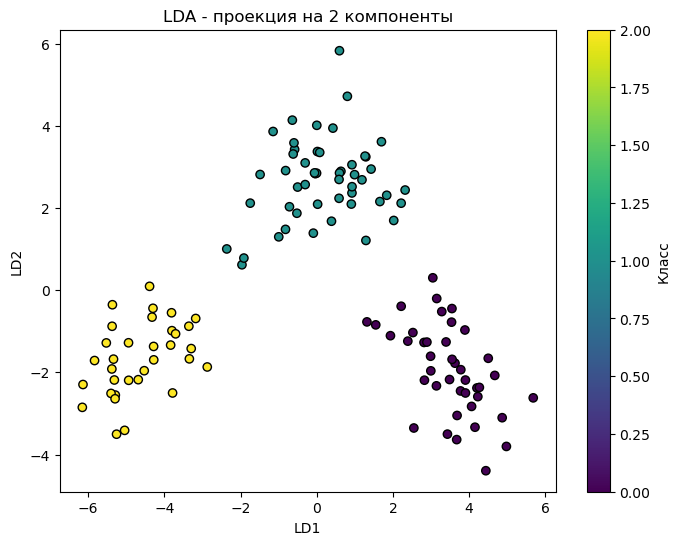

In [32]:
# Создание scatter plot для LDA:

# LDA проекция на обучающей выборке
X_train_LDA_vis = LDA_model.fit_transform(X_train, y_train)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_LDA_vis[:, 0], X_train_LDA_vis[:, 1], c=y_train, cmap='viridis', edgecolor='k')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA - проекция на 2 компоненты')
plt.colorbar(scatter, label='Класс')
plt.show()

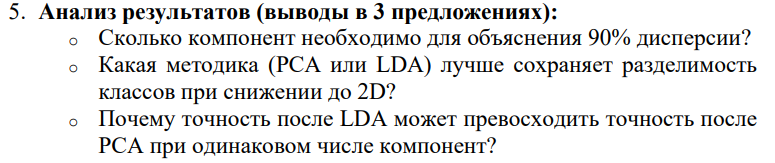

## Сколько компонент необходимо для объяснения 90% дисперсии?

Для объяснения дисперсии требуется 6-7 (из 13) компонент, ято позволяет сократить размерность почти в 2 раза, сохранив 90% информации.

## Какая методика (PCA или LDA) лучше сохраняет разделимость классов при снижении до 2D?

LDA лучше сохраняет разделимость классов, потому что использует информацию о метках классов и целенаправленно ищет направления, разделяющие классы.

## Почему точность после LDA может превосходить точность после PCA при одинаковом числе компонент?

Потому что LDA максимизирует отношение межклассовой дисперсии к внутреклассовой, а PCA максимизирует общую дисперсию. Так же, LDA использует метки классов при построении проекции, PCA же в свою очередь может терять важную для классификации информацию, если она лежит в направлениях с малой дисперсией.